In [1]:
# Import libraries from general conda environment
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import adjusted_rand_score, confusion_matrix, accuracy_score
from sklearn.utils.multiclass import unique_labels
from scipy.optimize import linear_sum_assignment
import copy as copy
import pickle
from functools import reduce

# Import libraries from UnitedNet
import sys
sys.path.append('..')
from src.interface import UnitedNet
from src.configs import *
from src.data import partitions,save_umap,generate_adata
from src.scripts import ordered_cmat,assignmene_align

# Import for SHAPs
import shap
import torch
import torch.nn as nn
from src.modules import submodel_trans, submodel_clus
from src.data import save_obj, load_obj, type_specific_mean
from src.plots import markers_chord_plot,type_relevance_chord_plot,feature_relevance_chord_plot,merge_sub_feature

# Import for imaging
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.neighbors import NearestNeighbors

/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def split_data(test_batch):
    adata_rna_train = adata_rna_all[adata_rna_all.obs['batch'] != test_batch]
    adata_morph_train = adata_morph_all[adata_morph_all.obs['batch'] != test_batch]
    adata_mrna_niche_train = adata_mrna_niche_all[adata_mrna_niche_all.obs['batch'] != test_batch]

    adata_rna_test = adata_rna_all[adata_rna_all.obs['batch'] == test_batch]
    adata_morph_test = adata_morph_all[adata_morph_all.obs['batch'] == test_batch]
    adata_mrna_niche_test = adata_mrna_niche_all[adata_mrna_niche_all.obs['batch'] == test_batch]

    return [adata_rna_train, adata_morph_train, adata_mrna_niche_train], [adata_rna_test, adata_morph_test,
                                                                         adata_mrna_niche_test]

In [3]:
from sklearn import preprocessing
def change_label(adata,batch):
    adata.obs['batch'] = batch
    adata.obs['imagecol'] = adata.obs['array_col']
    adata.obs['imagerow'] = adata.obs['array_row']
    adata.obs['label'] = adata.obs['cell_type']
    return adata

In [4]:
def pre_ps(adata_list,sc_pre = None):
    adata_list_all = [ad_x.copy() for ad_x in adata_list]
    scalars = []
    assert (adata_list_all[0].X>=0).all(), "poluted input"
    for idx, mod in enumerate(adata_list_all):
        t_x = mod.X
        if sc_pre != None:
            scaler = sc_pre[idx]
        else:
            scaler = preprocessing.StandardScaler().fit(t_x)
        t_x = scaler.transform(t_x)
        mod.X = t_x
        adata_list_all[idx] = mod
        scalars.append(scaler)

    return adata_list_all,scalars

In [5]:
technique = 'dbitseq'
data_path = f"../data/{technique}"
device = "cpu"

In [6]:
adata_niche_rna_train = sc.read_h5ad(f'{data_path}/adata_niche_rna_train.h5ad')
adata_niche_rna_test = sc.read_h5ad(f'{data_path}/adata_niche_rna_test.h5ad')

adata_rna_train = sc.read_h5ad(f'{data_path}/adata_rna_train.h5ad')
adata_rna_test = sc.read_h5ad(f'{data_path}/adata_rna_test.h5ad')

adata_protein_train = sc.read_h5ad(f'{data_path}/adata_protein_train.h5ad')
adata_protein_test = sc.read_h5ad(f'{data_path}/adata_protein_test.h5ad')

In [7]:
adata_rna_train = change_label(adata_rna_train,'train')
adata_protein_train=change_label(adata_protein_train,'train')
adata_niche_rna_train=change_label(adata_niche_rna_train,'train')

adata_rna_test = change_label(adata_rna_test,'test')
adata_protein_test = change_label(adata_protein_test,'test')
adata_niche_rna_test = change_label(adata_niche_rna_test,'test')

adatas_train = [adata_rna_train, adata_protein_train, adata_niche_rna_train]
adatas_test = [adata_rna_test, adata_protein_test, adata_niche_rna_test]

adatas_all = []
for ad_train, ad_test in zip(adatas_train,adatas_test):
    ad_all = ad_train.concatenate(ad_test,batch_key='sample')
    ad_all = change_label(ad_all,'test')
    adatas_all.append(ad_all)
adatas_all,_ = pre_ps(adatas_all)    
    
adatas_train,_ = pre_ps(adatas_train)   
adatas_test,_ = pre_ps(adatas_test)   

X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.


In [8]:
train_model = False
if train_model:
    technique = 'dbitseq'
    data_path = f"../data/{technique}"
    root_save_path = f"../saved_results/dbitseq"
    model = UnitedNet(root_save_path, device=device, technique=dbitseq_config)
    model.train(adatas_train,verbose=True)
    model.finetune(adatas_all,verbose=True)
    model.transfer(adatas_train, adatas_transfer = adatas_test, verbose=True)
    
else:
    technique = 'dbitseq'
    data_path = f"../data/{technique}"
    root_save_path = f"../saved_results/dbitseq"
    model = UnitedNet(root_save_path, device=device, technique=dbitseq_config)

Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.


Trying to modify attribute `.obs` of view, initializing view as actual.


Space 0
['Angptl2' 'Ap2s1' 'Crabp1' 'Ednrb' 'Enpp2' 'Gng3' 'Hsbp1' 'Igsf8' 'Irx2'
 'Mapk10' 'Mrpl57' 'Mrps16' 'Msl1' 'Ntrk3' 'Prmt8' 'Rnps1' 'Rpl17-ps8'
 'Ubr2' 'Wls' 'Zdbf2' 'CD102.ICAM2' 'CD117.KIT' 'CD201.EPCR' 'CD304.NPR1'
 'CD309.KDR' 'CD41.ITGA2B' 'CD45.PTPRC' 'CD55' 'ESAM' 'FCER1A'
 'Folate.Receptor' 'Ly.6A.E' 'MAdCAM.1' 'NK.1.1.KLRB1' 'Notch1' 'P2RY12'
 'SiglecH.SIGLEC' 'ErythroidCells.LY76' 'CD49d.ITGA4' 'CD326.Ep.CAM'
 'Ank2' 'Ap1s2' 'Btg1' 'Cblb' 'Ccdc34' 'Cdk5r1' 'Dpysl4' 'Fzd2' 'Gm11223'
 'Gm8292' 'Mrpl24' 'Phox2b' 'Pitx1' 'Pkdcc' 'Plod2' 'Rps13-ps1' 'Sec61a1'
 'Tenm3' 'Zfp157' 'Zyx' '0']
Space 1
['Afg3l1' 'Cenpb' 'Cnpy1' 'Col4a1' 'Crabp1' 'Crabp2' 'Ehmt2' 'En2' 'Itga4'
 'Kdm6b' 'Lamtor1' 'Lix1' 'Nhlh2' 'Otx2' 'Pax5' 'Rnd2' 'Rnps1' 'Sqle'
 'Ssr2' 'Wbp1' 'CD117.KIT' 'CD201.EPCR' 'CD304.NPR1' 'CD309.KDR'
 'CD45.PTPRC' 'CD55' 'CD63' 'ESAM' 'FCER1A' 'Folate.Receptor' 'Ly.6A.E'
 'MAdCAM.1' 'NK.1.1.KLRB1' 'Notch1' 'P2RY12' 'SiglecH.SIGLEC'
 'ErythroidCells.LY76' 'CD49d.ITGA4' 'C

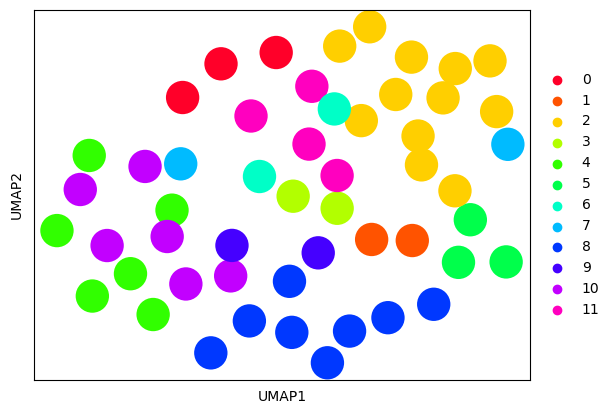

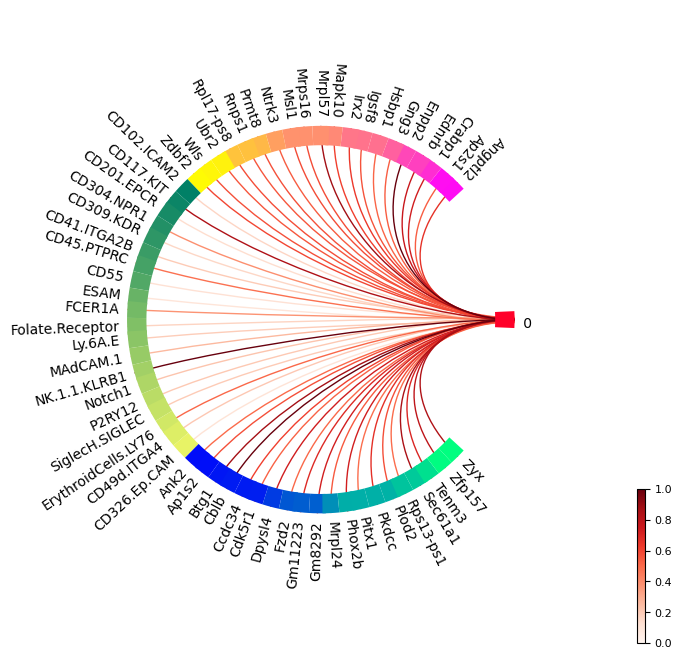

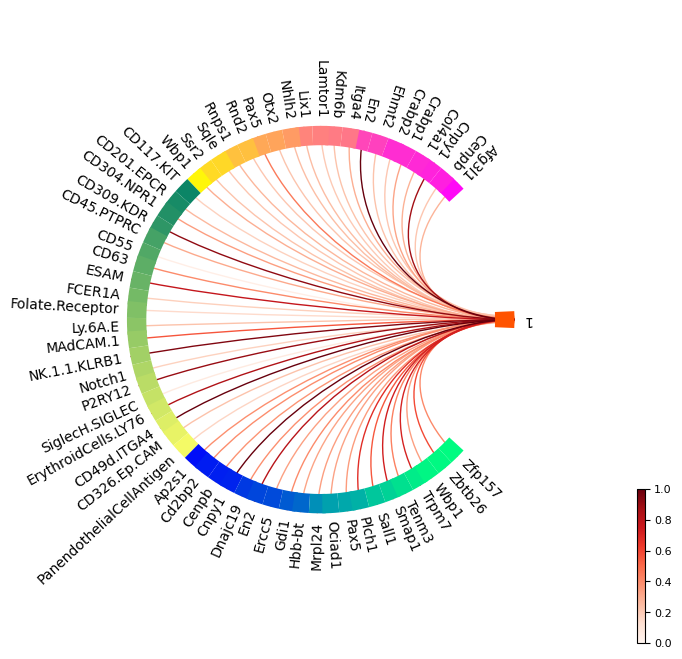

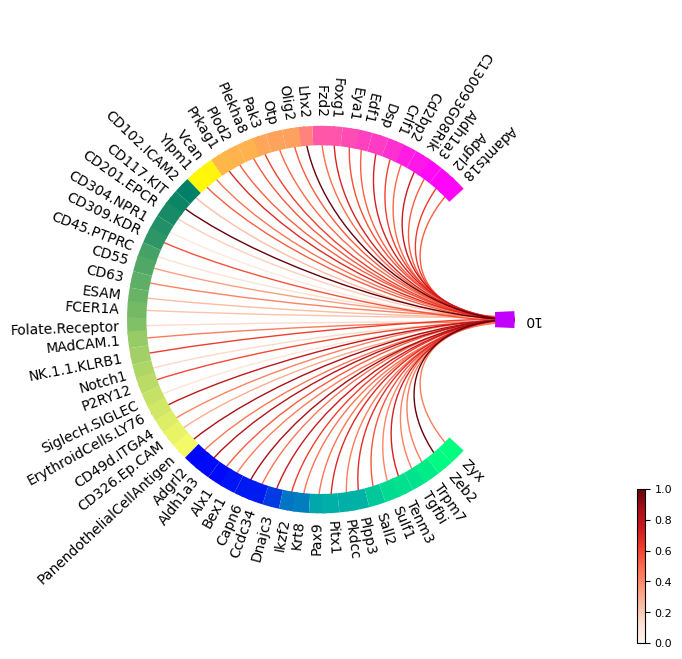

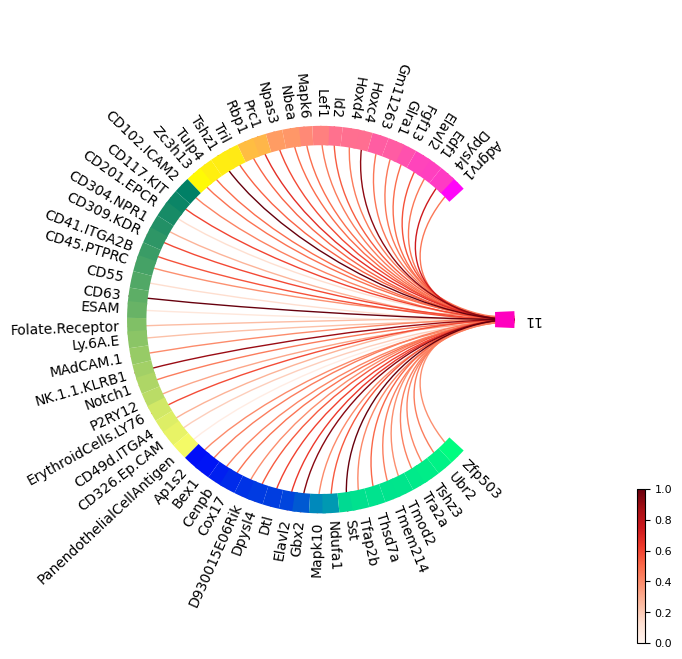

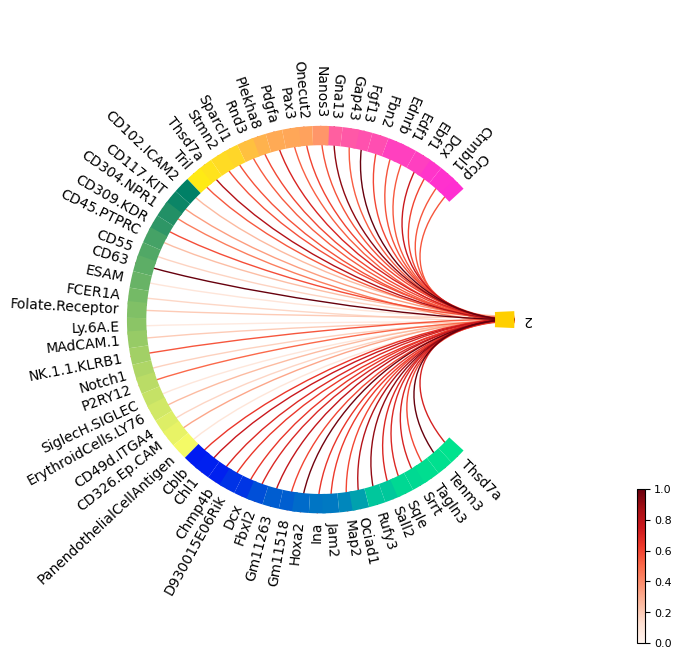

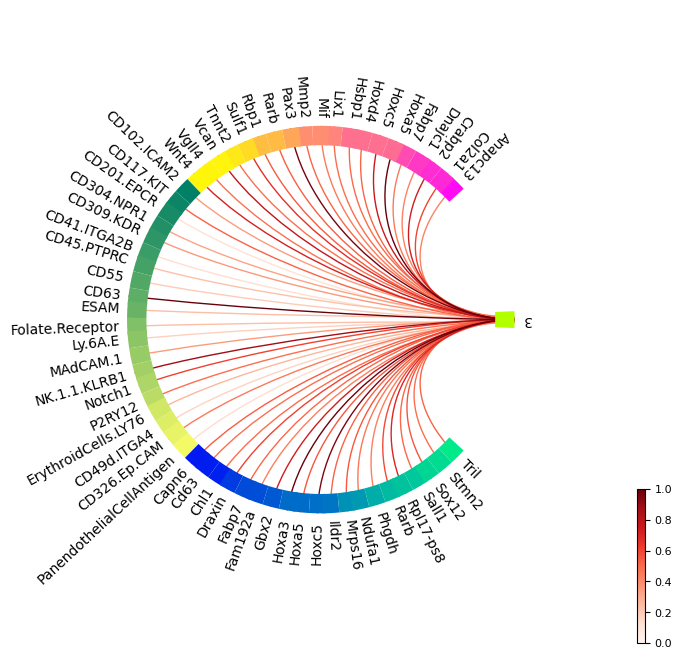

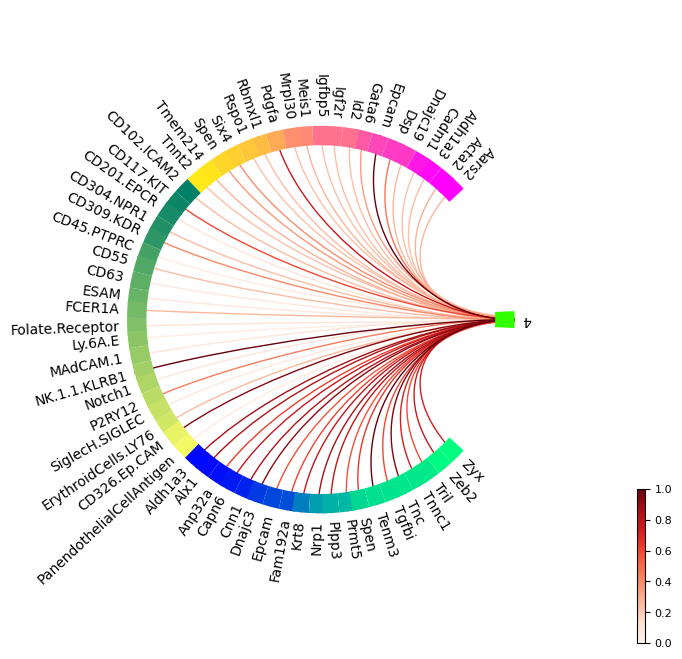

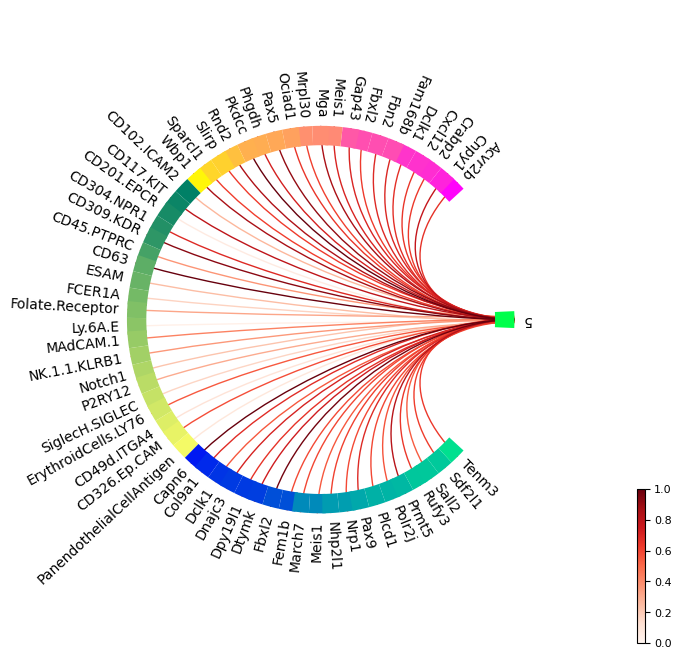

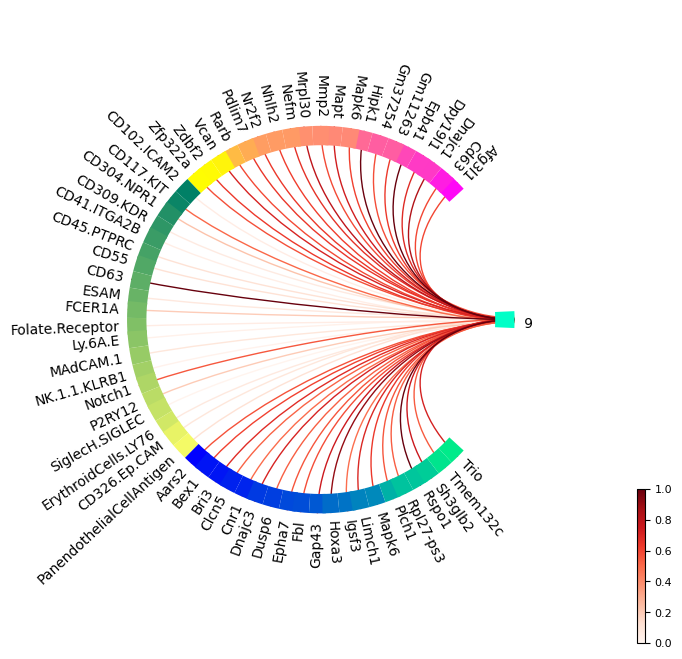

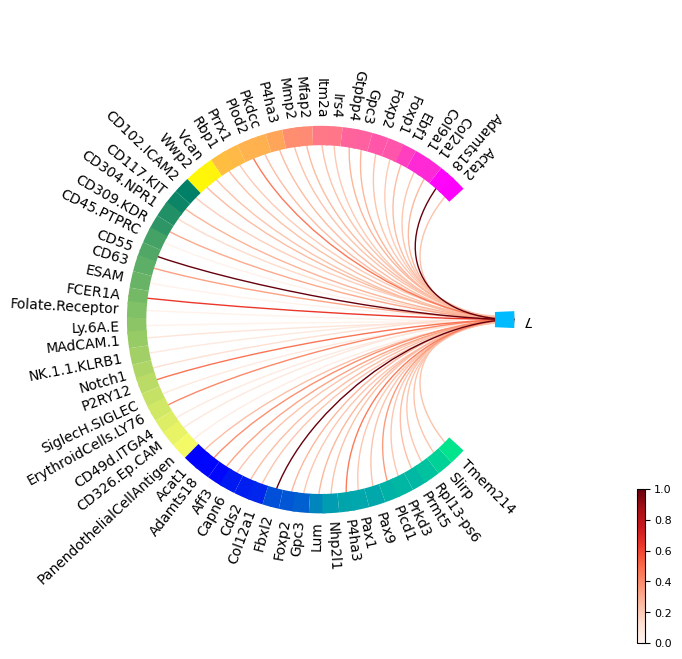

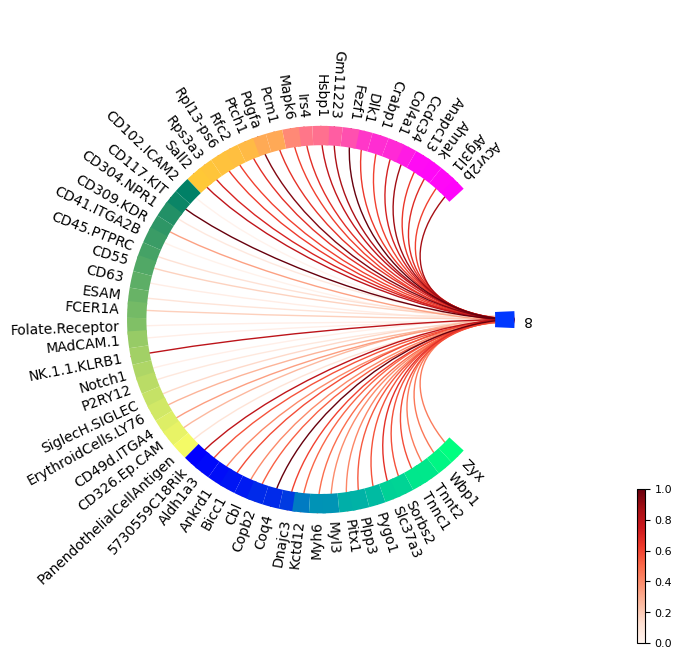

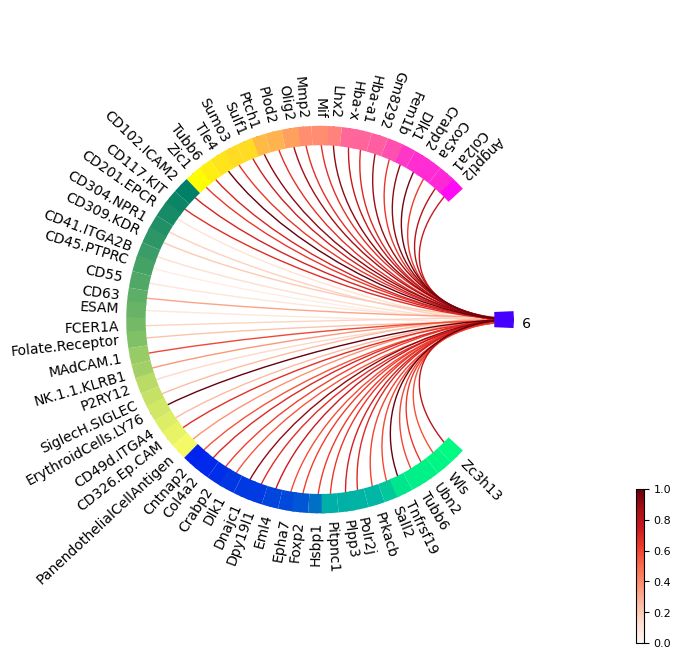

In [13]:
model = UnitedNet(root_save_path, device=device, technique=dbitseq_config)
model.load_model(f"{root_save_path}/transfer_best.pt",device=torch.device(device))
model.model.device_in_use = device

accuracy_matching = []
type_feature = {}
type_feature_major = {}
feature_relevance = {}
type_feature_shap_values = []

modality_names = ['RNA', 'PROTEINS', 'NITCHE']

calculate_shap = True

cluster_prototype_features = [type_specific_mean(ad_x,'label').to(device=model.device) for ad_x in adatas_all]


shap_value_target = {}

sp_idx = adatas_all[0].obs.groupby(["label"]).sample(n=4, random_state=1).index # 4 samples
test_type = [torch.tensor(adatas_all[0][sp_idx].X,device=model.device), 
             torch.tensor(adatas_all[1][sp_idx].X,device=model.device), 
             torch.tensor(adatas_all[2][sp_idx].X,device=model.device)]

adatas_all = [ad_x[sp_idx] for ad_x in adatas_all]
predict_label = model.predict_label(adatas_all)
adata_fused = model.infer(adatas_all)
predict_label_anno = adata_fused.obs['predicted_label']
adata_fused.obs['label'] = list(adatas_all[0].obs['label'])


new_features = True
top_features = {}
ct_num = len(adatas_all[0].obs["label"].unique())

root_save_path_relev = f'{root_save_path}/type_relevance'
if calculate_shap:
        sub = submodel_clus(model.model).to(model.device)
        # select a set of background examples to take an expectation over
        background = cluster_prototype_features
        e = shap.DeepExplainer(sub, background)
        # choose what to explain
        shap_values = e.shap_values(test_type,check_additivity=True)
        save_obj(root_save_path_relev,f'type_explain',shap_values)
else:
        shap_values = load_obj(root_save_path_relev,f'type_explain', ct_num,
                              [ads.shape for ads in adatas_all],type_rele=True,mod_num=2)
type_feature_shap_values.append(shap_values)

major_dict = {0: 'Space 0',
              1: 'Space 1',
              2: 'Space 2',
              3: 'Space 3',
              4: 'Space 4',
              5: 'Space 5',
              6: 'Space 6',
              7: 'Space 7',
              8: 'Space 8',
              9: 'Space 9',
              10: 'Space 10',
              11: 'Space 11',
              12: 'Space 12',
              12: 'Space 13'}

adatas_all_new,p_fe,p_fe_idx,p_l_less,pr_ty_dict = markers_chord_plot(adatas_all,predict_label,predict_label_anno,major_dict,subset_feature=False)
all_less_type = np.unique(p_l_less)

if 'predicted_label_colors' not in adata_fused.uns.keys():
        sc.pl.umap(adata_fused,color=['predicted_label'],palette='gist_rainbow',show=False,title='')
colors_type = dict(zip(adata_fused.obs['predicted_label'].cat.categories,adata_fused.uns['predicted_label_colors']))
all_type_features = type_relevance_chord_plot(shap_values, p_fe, p_fe_idx, p_l_less,predict_label, colors_type, all_less_type,f'{technique}',
                                  pr_ty_dict,thres=20,only_show_good=True, linewidth=1, linecolormap='Reds', node_width=5,fontsize_names=10,
                                              potential_coloarmaps=['spring', 'summer', 'winter', 'autumn'])
print(all_type_features)
type_feature = all_type_features
all_type_features_mj = merge_sub_feature(all_type_features,major_dict)
type_feature_major = all_type_features_mj

In [14]:
with open('./saved_results/dbitseq_type_relevance_robust.pkl', 'wb') as handle:
    pickle.dump(type_feature, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('./saved_results/dbitseq_type_major_relevance_robust.pkl', 'wb') as handle:
    pickle.dump(type_feature_major, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
with open('./saved_results/dbitseq_type_relevance_robust.pkl', 'rb') as handle:
    type_feature = pickle.load(handle)

with open('./saved_results/dbitseq_type_major_relevance_robust.pkl', 'rb') as handle:
    type_feature_major = pickle.load(handle)